# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Fill in before submitting:

Name of the Group: Group X

```
Student 1: 20250487
Student 2: 
Student 3: 
Student 4: 
Student 5: 
```


# 0. Setup & Imports


In [19]:
# Install dependencies (run once)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [20]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
# 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


## Instantiate and inspect the raw environment

`make_sepsis_env()` builds the discrete `ICU-Sepsis-v2` MDP and applies the fixed difficulty (`SOFA_BIAS=5.0`, `LAM=0.02`). We inspect its observation/action spaces and then extract the full transition and reward tensors `P` and `R` — Config A's defining affordance, which makes both Bellman backups and analytical policy evaluation possible later on.


In [ ]:
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

# Extract the full MDP model
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


## Random baseline: establish the performance floor

A uniformly random policy gives the minimum acceptable bar that any learned policy must clear. We use the same 1000-episode evaluation protocol throughout Config A so that every algorithm's numbers are directly comparable.


In [ ]:
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


## Visualise state visitation and reward structure

Two diagnostics about the MDP: which states the agent actually encounters under a random policy, and where the reward signal lives. Together they motivate the sparse-reward, short-horizon framing used by every algorithm in Config A.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.


## A.1 Value Iteration (model-based optimal reference)


In [24]:
# Value Iteration on the exposed MDP (uses P, R from cell 5)
V = np.zeros(N_STATES)
vi_deltas = []
vi_policy_changes = []
pi_prev = -np.ones(N_STATES, dtype=int)
for it in range(2000):
    Q_sa = R + GAMMA * P.dot(V)
    V_new = Q_sa.max(axis=1)
    pi_k = Q_sa.argmax(axis=1)
    delta = float(np.max(np.abs(V_new - V)))
    if it == 0:
        n_changed = N_STATES
    else:
        policy_change_mask = pi_k != pi_prev
        n_changed = int(policy_change_mask.sum())
    vi_deltas.append(delta)
    vi_policy_changes.append(n_changed)
    pi_prev = pi_k
    V = V_new
    if delta < 1e-10:
        break

V_VI = V
Q_VI = Q_sa
pi_VI = pi_k
vi_iters = len(vi_deltas)

# Evaluate greedy policy — same seeding scheme as the random baseline
env_eval = make_sepsis_env()
np.random.seed(SEED)
vi_returns_list = []
vi_lengths_list = []
for _ in range(1000):
    obs, _ = env_eval.reset(seed=np.random.randint(100_000))
    total_r = 0.0
    steps = 0
    done = False
    while not done:
        action = int(pi_VI[obs])
        obs, r, te, tr, _ = env_eval.step(action)
        total_r += r
        steps += 1
        done = te or tr
    vi_returns_list.append(total_r)
    vi_lengths_list.append(steps)
env_eval.close()

vi_returns = np.array(vi_returns_list)
vi_lengths = np.array(vi_lengths_list)
vi_survived = vi_returns > 0
vi_mean_ret = float(vi_returns.mean())
vi_surv = float(vi_survived.mean()) * 100
vi_mean_len = float(vi_lengths.mean())

# Live baseline comparison (rand_returns/rand_lengths come from cell 6)
rand_survived = rand_returns > 0
rand_mean = float(rand_returns.mean())
rand_surv = float(rand_survived.mean()) * 100

print(f'Value Iteration converged in {vi_iters} iterations (final Δ = {vi_deltas[-1]:.2e})')
print(f'Mean return    : {vi_mean_ret:.4f}    (random baseline: {rand_mean:.4f})')
print(f'Survival rate  : {vi_surv:.1f}%        (random baseline: {rand_surv:.1f}%)')
print(f'Mean ep length : {vi_mean_len:.1f} steps')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Value Iteration converged in 237 iterations (final Δ = 9.77e-11)
Mean return    : 0.7507    (random baseline: 0.5898)
Survival rate  : 78.8%        (random baseline: 69.0%)
Mean ep length : 9.8 steps


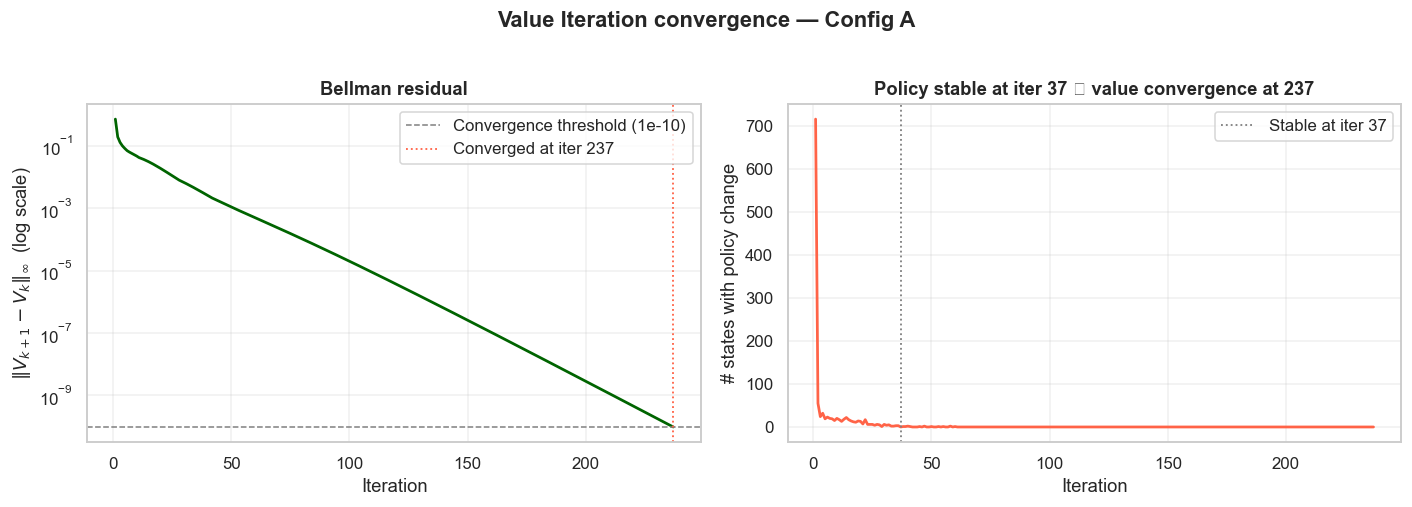

In [25]:
# Value Iteration convergence — Bellman residual + policy stability per iteration.
# Left panel: ‖V_{k+1} − V_k‖_∞ on log-y — geometric decay of the value function.
# Right panel: number of states whose greedy action changes at iter k —
# the policy typically stabilises well before V does, so the remaining iterations
# are numerical polish without decision-making consequence.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

iters_axis = np.arange(1, vi_iters + 1)
vi_deltas_arr = np.array(vi_deltas)
vi_policy_changes_arr = np.array(vi_policy_changes)

# First iteration k >= 2 where the policy is identical to the previous iteration.
post_init_zero_mask = vi_policy_changes_arr[1:] == 0
if post_init_zero_mask.any():
    first_zero_slice_idx = int(np.argmax(post_init_zero_mask))
    iter_policy_stable = first_zero_slice_idx + 2
else:
    iter_policy_stable = vi_iters

axes[0].semilogy(iters_axis, vi_deltas_arr, color='darkgreen', linewidth=1.8)
axes[0].axhline(1e-10, color='gray', linestyle='--', linewidth=1.0,
                label='Convergence threshold (1e-10)')
axes[0].axvline(vi_iters, color='tomato', linestyle=':', linewidth=1.2,
                label=f'Converged at iter {vi_iters}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$\|V_{k+1} - V_k\|_\infty$  (log scale)')
axes[0].set_title('Bellman residual', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, which='both', alpha=0.3)

policy_panel_title = f'Policy stable at iter {iter_policy_stable} ≪ value convergence at {vi_iters}'
axes[1].plot(iters_axis, vi_policy_changes_arr, color='tomato', linewidth=1.8)
axes[1].axvline(iter_policy_stable, color='gray', linestyle=':', linewidth=1.2,
                label=f'Stable at iter {iter_policy_stable}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('# states with policy change')
axes[1].set_title(policy_panel_title, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Value Iteration convergence — Config A', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_vi_convergence.png', bbox_inches='tight')
plt.show()


In [26]:
# Analytical policy evaluation — exact J(π) via linear solve (Config-A affordance).
# Because the MDP is known, J(π) = d_0 · V_π is computable exactly without rollouts:
#   V_π[non_term] = (I − γ P_π[non_term, non_term])^(-1) · R_π[non_term]
# MC eval (vi_returns above, ql_returns_per_seed in A.2) is kept for the return
# distribution (cell 17) and as a simulator-vs-model sanity check.

# Auto-detect absorbing states (self-loop prob = 1 under every action).
# In ICU-Sepsis the gym wrapper terminates on observing 713 (died) or 714
# (survived), but the underlying MDP continues both into 715 — the only true
# absorber. For the linear solve we need the structural absorber set;
# using {713, 714} would make (I − γ P_π[non_term]) singular for random π.
all_states = np.arange(N_STATES)
self_loop_prob = np.zeros((N_STATES, N_ACTIONS))
for s in all_states:
    self_loop_prob[s, :] = P[s, :, s]
is_absorbing_per_action = self_loop_prob == 1.0
is_absorbing = is_absorbing_per_action.all(axis=1)
NON_TERMINAL = all_states[~is_absorbing]


def analytical_J(policy=None):
    """Exact expected return d_0 · V_π.

    policy: deterministic policy (N_STATES,) action array, or None for the
        uniform-random policy.
    Returns (J, V_π) with V_π zero on terminal states.
    """
    if policy is None:
        P_pi = P.mean(axis=1)
        R_pi = R.mean(axis=1)
    else:
        state_idx = np.arange(N_STATES)
        P_pi = P[state_idx, policy, :]
        R_pi = R[state_idx, policy]

    P_nt = P_pi[np.ix_(NON_TERMINAL, NON_TERMINAL)]
    R_nt = R_pi[NON_TERMINAL]
    A_mat = np.eye(len(NON_TERMINAL)) - GAMMA * P_nt

    V_pi = np.zeros(N_STATES)
    V_pi[NON_TERMINAL] = np.linalg.solve(A_mat, R_nt)
    J = float(raw._d_0 @ V_pi)
    out = (J, V_pi)
    return out


J_rand_exact, _ = analytical_J(policy=None)
J_VI_exact, V_VI_exact = analytical_J(pi_VI)


mc_vs_analytical_gap = abs(vi_mean_ret - J_VI_exact)

print('Analytical J (exact, no sampling):')
print(f'  Random policy       : {J_rand_exact:.4f}')
print(f'  VI policy           : {J_VI_exact:.4f}')
print(f'  MC mean (1000, VI)  : {vi_mean_ret:.4f}   → simulator-model gap {mc_vs_analytical_gap:.4f}')


Analytical J (exact, no sampling):
  Random policy       : 0.6053
  VI policy           : 0.7853
  MC mean (1000, VI)  : 0.7507   → simulator-model gap 0.0346


## A.2 Q-Learning (model-free)


### Q-Learning training across 3 seeds

Q-Learning is the model-free TD(0) counterpart to the VI cell above. The point of including it despite having `P` and `R` is to validate that an agent without access to the MDP model can recover essentially the same policy by interacting with the simulator. We train across 3 seeds so the learning curve can show mean ± std, and pick the median seed for downstream policy visualisations.


In [ ]:
N_EPISODES = 200_000
ALPHA = 0.1
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_END = int(0.8 * N_EPISODES)
SEEDS = [0, 1, 2]
SNAPSHOT_EVERY = 5_000  # snapshot Q every N episodes for the optimality-gap plot

# Pre-compute the (deterministic) ε schedule once for plotting
ql_eps_schedule = np.empty(N_EPISODES)
for ep in range(N_EPISODES):
    frac = min(ep / EPS_DECAY_END, 1.0)
    ql_eps_schedule[ep] = EPS_START + (EPS_END - EPS_START) * frac

# Snapshot episode indices (1-indexed for plotting, plus final)
snapshot_eps_list = list(range(SNAPSHOT_EVERY, N_EPISODES + 1, SNAPSHOT_EVERY))
if snapshot_eps_list[-1] != N_EPISODES:
    snapshot_eps_list.append(N_EPISODES)
snapshot_eps = np.array(snapshot_eps_list)

Q_QL_per_seed = []
ql_curves = np.empty((len(SEEDS), N_EPISODES))
ql_lengths_train = np.empty((len(SEEDS), N_EPISODES))
ql_td_errors = np.empty((len(SEEDS), N_EPISODES))
ql_snapshots_per_seed = []  # list[seed] of list[snapshot] of Q-table copies

for s_idx, seed in enumerate(SEEDS):
    env_train = make_sepsis_env()
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    seed_snapshots = []

    for ep in range(N_EPISODES):
        eps = ql_eps_schedule[ep]
        obs, _ = env_train.reset(seed=int(rng.integers(0, 100_000)))
        total_r = 0.0
        steps = 0
        abs_td_sum = 0.0
        done = False
        while not done:
            if rng.random() < eps:
                action = int(env_train.action_space.sample())
            else:
                action = int(Q[obs].argmax())
            next_obs, r, te, tr, _ = env_train.step(action)
            terminal = te or tr
            if terminal:
                target = r
            else:
                target = r + GAMMA * Q[next_obs].max()
            td_error = target - Q[obs, action]
            Q[obs, action] += ALPHA * td_error
            abs_td_sum += abs(td_error)
            total_r += r
            steps += 1
            obs = next_obs
            done = terminal

        ql_curves[s_idx, ep] = total_r
        ql_lengths_train[s_idx, ep] = steps
        ql_td_errors[s_idx, ep] = abs_td_sum / max(steps, 1)

        if (ep + 1) in snapshot_eps_list:
            seed_snapshots.append(Q.copy())

    env_train.close()
    Q_QL_per_seed.append(Q)
    ql_snapshots_per_seed.append(seed_snapshots)

# Evaluate each seed's greedy policy on identical episode seeds (mirrors VI/random)
ql_returns_per_seed = []
ql_lengths_per_seed = []
for Q in Q_QL_per_seed:
    pi_seed = Q.argmax(axis=1)
    env_eval = make_sepsis_env()
    np.random.seed(SEED)
    seed_returns = []
    seed_lengths = []
    for _ in range(1000):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r = 0.0
        steps = 0
        done = False
        while not done:
            action = int(pi_seed[obs])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r
            steps += 1
            done = te or tr
        seed_returns.append(total_r)
        seed_lengths.append(steps)
    env_eval.close()
    ql_returns_per_seed.append(np.array(seed_returns))
    ql_lengths_per_seed.append(np.array(seed_lengths))

# Per-seed eval summary (loops, not comprehensions)
seed_means_list = []
seed_survs_list = []
seed_lens_list = []
for r_arr, l_arr in zip(ql_returns_per_seed, ql_lengths_per_seed):
    seed_means_list.append(r_arr.mean())
    survival_pct = float((r_arr > 0).mean()) * 100
    seed_survs_list.append(survival_pct)
    seed_lens_list.append(l_arr.mean())
ql_means = np.array(seed_means_list)
ql_survs = np.array(seed_survs_list)
ql_lens = np.array(seed_lens_list)

# Pick the "median seed" for the policy-viz plot — closest mean eval return to the median
median_value = float(np.median(ql_means))
distances = np.abs(ql_means - median_value)
median_seed_idx = int(distances.argmin())
Q_QL = Q_QL_per_seed[median_seed_idx]
pi_QL = Q_QL.argmax(axis=1)

# Pooled stats across all 3 seeds
ql_pooled_returns = np.concatenate(ql_returns_per_seed)
ql_pooled_lengths = np.concatenate(ql_lengths_per_seed)
ql_mean_ret = float(ql_pooled_returns.mean())
ql_surv = float((ql_pooled_returns > 0).mean()) * 100
ql_mean_len = float(ql_pooled_lengths.mean())

print(f'Q-Learning trained for {N_EPISODES} episodes × {len(SEEDS)} seeds (α={ALPHA}, ε: {EPS_START}→{EPS_END})')
print(f'  Per-seed mean return   : {np.array2string(ql_means, precision=4)}')
print(f'  Per-seed survival rate : {np.array2string(ql_survs, precision=1)}%')
print(f'  Pooled mean return     : {ql_mean_ret:.4f}    (VI: {vi_mean_ret:.4f}, random: {rand_mean:.4f})')
print(f'  Pooled survival rate   : {ql_surv:.1f}%        (VI: {vi_surv:.1f}%, random: {rand_surv:.1f}%)')
print(f'  Pooled mean ep length  : {ql_mean_len:.1f} steps')
print(f'  Median seed for policy viz : seed={SEEDS[median_seed_idx]} (mean eval return {ql_means[median_seed_idx]:.4f})')
print(f'  Snapshots per seed     : {len(snapshot_eps)} (every {SNAPSHOT_EVERY} episodes)')


### Q-Learning learning curve

Rolling-500-episode mean return averaged across seeds with a ±1 std band, and the ε schedule overlaid on a twin axis. The horizontal dashed line marks the Value Iteration ceiling.


In [ ]:
WINDOW = 500


def rolling_mean(arr, window):
    if len(arr) < window:
        return arr.copy()
    cumsum = np.cumsum(np.insert(arr, 0, 0.0))
    result = (cumsum[window:] - cumsum[:-window]) / window
    return result


# Per-seed rolling means, then aggregate across seeds
rolling_per_seed = []
for s_idx in range(len(SEEDS)):
    seed_curve = ql_curves[s_idx]
    seed_rolling = rolling_mean(seed_curve, WINDOW)
    rolling_per_seed.append(seed_rolling)
rolling_stack = np.vstack(rolling_per_seed)
rolling_mean_across_seeds = rolling_stack.mean(axis=0)
rolling_std_across_seeds = rolling_stack.std(axis=0)
x_axis = np.arange(WINDOW - 1, N_EPISODES)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(x_axis, rolling_mean_across_seeds, color='steelblue', linewidth=2.0,
         label=f'Q-Learning mean across {len(SEEDS)} seeds (rolling-{WINDOW})')
upper_band = rolling_mean_across_seeds + rolling_std_across_seeds
lower_band = rolling_mean_across_seeds - rolling_std_across_seeds
ax1.fill_between(x_axis, lower_band, upper_band, color='steelblue', alpha=0.2,
                 label='±1 std across seeds')

ax1.axhline(vi_mean_ret, color='darkgreen', linestyle='--', linewidth=1.5,
            label=f'Value Iteration ({vi_mean_ret:.3f})')
ax1.axhline(rand_mean, color='gray', linestyle=':', linewidth=1.5,
            label=f'Random baseline ({rand_mean:.3f})')

ax1.set_xlabel('Training episode')
ax1.set_ylabel('Episode return (rolling mean)')
ax1.set_title('Q-Learning learning curve — Config A', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Twin axis for ε schedule
ax2 = ax1.twinx()
ax2.plot(np.arange(N_EPISODES), ql_eps_schedule, color='tomato', linewidth=1.2,
         alpha=0.7, label='ε (exploration rate)')
ax2.set_ylabel('ε', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_qlearning_curve.png', bbox_inches='tight')
plt.show()


## A.3 SARSA (on-policy TD)

SARSA is the on-policy counterpart to Q-Learning. The two differ in a single line of the update: Q-Learning bootstraps from `max_{a'} Q(s', a')` (the value of the *greedy* next action), while SARSA bootstraps from `Q(s', a')` for the action `a'` actually sampled under the current ε-greedy policy.

This distinction matters in a clinical-safety frame. Q-Learning learns the value of a deterministic optimum *as if* the agent will never explore again; SARSA learns the value of the policy the agent actually executes, including its ε-greedy exploratory moves. When exploration steps can hurt patients, SARSA's risk-aware estimate tends to favour policies whose neighbourhood under exploration is also acceptable.

We mirror the Q-Learning training setup exactly (200k episodes × 3 seeds, α=0.1, ε decay 1.0→0.05 over 80% of training, identical 1000-episode evaluation set) so the two algorithms are directly comparable in the A.4 table and the optimality-gap plot.


### SARSA training across 3 seeds

Same hyperparameters and ε schedule as Q-Learning. The only change is in the bootstrap target. Q-snapshots are also captured here for the optimality-gap analysis.


In [ ]:
# SARSA — on-policy TD counterpart to Q-Learning above.
# Hyperparameters mirror Q-Learning exactly so the comparison is apples-to-apples.

Q_SARSA_per_seed = []
sarsa_curves = np.empty((len(SEEDS), N_EPISODES))
sarsa_lengths_train = np.empty((len(SEEDS), N_EPISODES))
sarsa_td_errors = np.empty((len(SEEDS), N_EPISODES))
sarsa_snapshots_per_seed = []


def eps_greedy_action(Q_row, eps_val, n_actions, rng_local, env_local):
    if rng_local.random() < eps_val:
        out = int(env_local.action_space.sample())
    else:
        out = int(Q_row.argmax())
    return out


for s_idx, seed in enumerate(SEEDS):
    env_train = make_sepsis_env()
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    seed_snapshots = []

    for ep in range(N_EPISODES):
        eps = ql_eps_schedule[ep]  # reuse the QL schedule verbatim
        obs, _ = env_train.reset(seed=int(rng.integers(0, 100_000)))
        action = eps_greedy_action(Q[obs], eps, N_ACTIONS, rng, env_train)
        total_r = 0.0
        steps = 0
        abs_td_sum = 0.0
        done = False
        while not done:
            next_obs, r, te, tr, _ = env_train.step(action)
            terminal = te or tr
            if terminal:
                target = r
                next_action = 0  # unused
            else:
                next_action = eps_greedy_action(Q[next_obs], eps, N_ACTIONS, rng, env_train)
                target = r + GAMMA * Q[next_obs, next_action]
            td_error = target - Q[obs, action]
            Q[obs, action] += ALPHA * td_error
            abs_td_sum += abs(td_error)
            total_r += r
            steps += 1
            obs = next_obs
            action = next_action
            done = terminal

        sarsa_curves[s_idx, ep] = total_r
        sarsa_lengths_train[s_idx, ep] = steps
        sarsa_td_errors[s_idx, ep] = abs_td_sum / max(steps, 1)

        if (ep + 1) in snapshot_eps_list:
            seed_snapshots.append(Q.copy())

    env_train.close()
    Q_SARSA_per_seed.append(Q)
    sarsa_snapshots_per_seed.append(seed_snapshots)

# Evaluate each seed's greedy policy on the same 1000-ep fixed seed set
sarsa_returns_per_seed = []
sarsa_lengths_per_seed = []
for Q in Q_SARSA_per_seed:
    pi_seed = Q.argmax(axis=1)
    env_eval = make_sepsis_env()
    np.random.seed(SEED)
    seed_returns = []
    seed_lengths = []
    for _ in range(1000):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r = 0.0
        steps = 0
        done = False
        while not done:
            action = int(pi_seed[obs])
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r
            steps += 1
            done = te or tr
        seed_returns.append(total_r)
        seed_lengths.append(steps)
    env_eval.close()
    sarsa_returns_per_seed.append(np.array(seed_returns))
    sarsa_lengths_per_seed.append(np.array(seed_lengths))

sarsa_seed_means_list = []
sarsa_seed_survs_list = []
sarsa_seed_lens_list = []
for r_arr, l_arr in zip(sarsa_returns_per_seed, sarsa_lengths_per_seed):
    sarsa_seed_means_list.append(r_arr.mean())
    survival_pct = float((r_arr > 0).mean()) * 100
    sarsa_seed_survs_list.append(survival_pct)
    sarsa_seed_lens_list.append(l_arr.mean())
sarsa_means = np.array(sarsa_seed_means_list)
sarsa_survs = np.array(sarsa_seed_survs_list)
sarsa_lens = np.array(sarsa_seed_lens_list)

# Median seed for policy viz (same logic as QL)
sarsa_median_value = float(np.median(sarsa_means))
sarsa_distances = np.abs(sarsa_means - sarsa_median_value)
sarsa_median_seed_idx = int(sarsa_distances.argmin())
Q_SARSA = Q_SARSA_per_seed[sarsa_median_seed_idx]
pi_SARSA = Q_SARSA.argmax(axis=1)

# Pooled stats
sarsa_pooled_returns = np.concatenate(sarsa_returns_per_seed)
sarsa_pooled_lengths = np.concatenate(sarsa_lengths_per_seed)
sarsa_mean_ret = float(sarsa_pooled_returns.mean())
sarsa_surv = float((sarsa_pooled_returns > 0).mean()) * 100
sarsa_mean_len = float(sarsa_pooled_lengths.mean())

print(f'SARSA trained for {N_EPISODES} episodes × {len(SEEDS)} seeds (α={ALPHA}, ε: {EPS_START}→{EPS_END})')
print(f'  Per-seed mean return   : {np.array2string(sarsa_means, precision=4)}')
print(f'  Per-seed survival rate : {np.array2string(sarsa_survs, precision=1)}%')
print(f'  Pooled mean return     : {sarsa_mean_ret:.4f}    (QL: {ql_mean_ret:.4f}, VI: {vi_mean_ret:.4f})')
print(f'  Pooled survival rate   : {sarsa_surv:.1f}%        (QL: {ql_surv:.1f}%, VI: {vi_surv:.1f}%)')
print(f'  Pooled mean ep length  : {sarsa_mean_len:.1f} steps')
print(f'  Median seed for policy viz : seed={SEEDS[sarsa_median_seed_idx]} (mean eval return {sarsa_means[sarsa_median_seed_idx]:.4f})')


### SARSA learning curve

Same rolling-mean across-seeds presentation as the Q-Learning curve, for direct visual comparison.


In [ ]:
sarsa_rolling_per_seed = []
for s_idx in range(len(SEEDS)):
    seed_rolling = rolling_mean(sarsa_curves[s_idx], WINDOW)
    sarsa_rolling_per_seed.append(seed_rolling)
sarsa_rolling_stack = np.vstack(sarsa_rolling_per_seed)
sarsa_rolling_mean_across_seeds = sarsa_rolling_stack.mean(axis=0)
sarsa_rolling_std_across_seeds = sarsa_rolling_stack.std(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(x_axis, sarsa_rolling_mean_across_seeds, color='darkorange', linewidth=2.0,
         label=f'SARSA mean across {len(SEEDS)} seeds (rolling-{WINDOW})')
sarsa_upper = sarsa_rolling_mean_across_seeds + sarsa_rolling_std_across_seeds
sarsa_lower = sarsa_rolling_mean_across_seeds - sarsa_rolling_std_across_seeds
ax1.fill_between(x_axis, sarsa_lower, sarsa_upper, color='darkorange', alpha=0.2,
                 label='±1 std across seeds')

# Overlay Q-Learning mean (no band, for clean reference)
ax1.plot(x_axis, rolling_mean_across_seeds, color='steelblue', linewidth=1.2,
         alpha=0.7, label='Q-Learning mean (for comparison)')
ax1.axhline(vi_mean_ret, color='darkgreen', linestyle='--', linewidth=1.5,
            label=f'Value Iteration ({vi_mean_ret:.3f})')
ax1.axhline(rand_mean, color='gray', linestyle=':', linewidth=1.5,
            label=f'Random baseline ({rand_mean:.3f})')

ax1.set_xlabel('Training episode')
ax1.set_ylabel('Episode return (rolling mean)')
ax1.set_title('SARSA learning curve — Config A', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(np.arange(N_EPISODES), ql_eps_schedule, color='tomato', linewidth=1.2,
         alpha=0.7, label='ε (exploration rate)')
ax2.set_ylabel('ε', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_sarsa_curve.png', bbox_inches='tight')
plt.show()


## A.4 Algorithm comparison


In [ ]:
# Config A results table — Random vs. Q-Learning vs. SARSA vs. Value Iteration
def bootstrap_survival_ci(returns_arr, n_resample=1000, ci=0.95, seed=SEED):
    rng_bs = np.random.default_rng(seed)
    n = len(returns_arr)
    survived_mask = returns_arr > 0
    boot_means = np.empty(n_resample)
    for i in range(n_resample):
        idx = rng_bs.integers(0, n, size=n)
        boot_means[i] = survived_mask[idx].mean()
    alpha = (1.0 - ci) / 2.0
    lo = float(np.quantile(boot_means, alpha)) * 100
    hi = float(np.quantile(boot_means, 1.0 - alpha)) * 100
    return lo, hi


# Random
rand_return_mean = float(rand_returns.mean())
rand_return_std = float(rand_returns.std())
rand_survival = float((rand_returns > 0).mean()) * 100
rand_surv_lo, rand_surv_hi = bootstrap_survival_ci(rand_returns)
rand_length_mean = float(rand_lengths.mean())

# Q-Learning
ql_return_std = float(ql_pooled_returns.std())
ql_surv_lo, ql_surv_hi = bootstrap_survival_ci(ql_pooled_returns)

# SARSA
sarsa_return_std = float(sarsa_pooled_returns.std())
sarsa_surv_lo, sarsa_surv_hi = bootstrap_survival_ci(sarsa_pooled_returns)

# Value Iteration
vi_return_std = float(vi_returns.std())
vi_surv_lo, vi_surv_hi = bootstrap_survival_ci(vi_returns)

# Analytical J per learned policy
ql_J_values = []
for Q_seed in Q_QL_per_seed:
    pi_seed = Q_seed.argmax(axis=1)
    J_seed, _ = analytical_J(pi_seed)
    ql_J_values.append(J_seed)
ql_J_per_seed = np.array(ql_J_values)
ql_J_mean = float(ql_J_per_seed.mean())
ql_J_std = float(ql_J_per_seed.std())

sarsa_J_values = []
for Q_seed in Q_SARSA_per_seed:
    pi_seed = Q_seed.argmax(axis=1)
    J_seed, _ = analytical_J(pi_seed)
    sarsa_J_values.append(J_seed)
sarsa_J_per_seed = np.array(sarsa_J_values)
sarsa_J_mean = float(sarsa_J_per_seed.mean())
sarsa_J_std = float(sarsa_J_per_seed.std())

random_J_str = f'{J_rand_exact:.4f}'
ql_J_str = f'{ql_J_mean:.4f} ± {ql_J_std:.4f}'
sarsa_J_str = f'{sarsa_J_mean:.4f} ± {sarsa_J_std:.4f}'
vi_J_str = f'{J_VI_exact:.4f}'
analytical_col = [random_J_str, ql_J_str, sarsa_J_str, vi_J_str]

# Δ vs random
ql_delta_return = ql_mean_ret - rand_return_mean
ql_delta_surv = ql_surv - rand_survival
sarsa_delta_return = sarsa_mean_ret - rand_return_mean
sarsa_delta_surv = sarsa_surv - rand_survival
vi_delta_return = vi_mean_ret - rand_return_mean
vi_delta_surv = vi_surv - rand_survival

# Format strings
random_return_str = f'{rand_return_mean:.4f} ± {rand_return_std:.4f}'
ql_return_str = f'{ql_mean_ret:.4f} ± {ql_return_std:.4f}'
sarsa_return_str = f'{sarsa_mean_ret:.4f} ± {sarsa_return_std:.4f}'
vi_return_str = f'{vi_mean_ret:.4f} ± {vi_return_std:.4f}'

random_surv_str = f'{rand_survival:.1f}% [{rand_surv_lo:.1f}, {rand_surv_hi:.1f}]'
ql_surv_str = f'{ql_surv:.1f}% [{ql_surv_lo:.1f}, {ql_surv_hi:.1f}]'
sarsa_surv_str = f'{sarsa_surv:.1f}% [{sarsa_surv_lo:.1f}, {sarsa_surv_hi:.1f}]'
vi_surv_str = f'{vi_surv:.1f}% [{vi_surv_lo:.1f}, {vi_surv_hi:.1f}]'

ql_convergence_str = f'{N_EPISODES:,} eps × {len(SEEDS)} seeds'
sarsa_convergence_str = f'{N_EPISODES:,} eps × {len(SEEDS)} seeds'
vi_convergence_str = f'{vi_iters} iters (Δ<1e-10)'

ql_delta_return_str = f'{ql_delta_return:+.4f}'
ql_delta_surv_str = f'{ql_delta_surv:+.1f} pp'
sarsa_delta_return_str = f'{sarsa_delta_return:+.4f}'
sarsa_delta_surv_str = f'{sarsa_delta_surv:+.1f} pp'
vi_delta_return_str = f'{vi_delta_return:+.4f}'
vi_delta_surv_str = f'{vi_delta_surv:+.1f} pp'

algorithm_col = ['Random', 'Q-Learning', 'SARSA', 'Value Iteration']
return_col = [random_return_str, ql_return_str, sarsa_return_str, vi_return_str]
survival_col = [random_surv_str, ql_surv_str, sarsa_surv_str, vi_surv_str]
length_col = [f'{rand_length_mean:.1f}', f'{ql_mean_len:.1f}', f'{sarsa_mean_len:.1f}', f'{vi_mean_len:.1f}']
convergence_col = ['—', ql_convergence_str, sarsa_convergence_str, vi_convergence_str]
delta_return_col = ['—', ql_delta_return_str, sarsa_delta_return_str, vi_delta_return_str]
delta_surv_col = ['—', ql_delta_surv_str, sarsa_delta_surv_str, vi_delta_surv_str]

results_df = pd.DataFrame({
    'Algorithm': algorithm_col,
    'Analytical J (exact)': analytical_col,
    'Mean return ± std': return_col,
    'Survival % [95% CI]': survival_col,
    'Mean ep length': length_col,
    'Convergence': convergence_col,
    'Δ return vs random': delta_return_col,
    'Δ survival vs random': delta_surv_col,
})

display(results_df)


In [ ]:
# Return-distribution comparison across Random / Q-Learning / SARSA / VI (all pooled)
# Episode returns are nearly bimodal (death=0/intensity-penalty, survival≈+1), so a
# violin reads better than a histogram for the side-by-side comparison.
fig, ax = plt.subplots(figsize=(11, 5))

dataset = [rand_returns, ql_pooled_returns, sarsa_pooled_returns, vi_returns]
labels = ['Random',
          f'Q-Learning\n(pooled, {len(SEEDS)} seeds)',
          f'SARSA\n(pooled, {len(SEEDS)} seeds)',
          'Value Iteration']
colors = ['gray', 'steelblue', 'darkorange', 'darkgreen']

parts = ax.violinplot(dataset, showmeans=False, showmedians=False, showextrema=False,
                     widths=0.85)
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.45)
    body.set_edgecolor('black')

positions = np.arange(1, len(dataset) + 1)
means = []
survivals = []
for arr in dataset:
    means.append(float(arr.mean()))
    surv_pct = float((arr > 0).mean()) * 100
    survivals.append(surv_pct)
ax.scatter(positions, means, color='black', s=60, zorder=3, label='Mean return')

for x, m, s in zip(positions, means, survivals):
    annotation_text = f'μ={m:.3f}\nsurv={s:.1f}%'
    ax.annotate(annotation_text, xy=(x, m), xytext=(x + 0.15, m),
                fontsize=9, va='center')

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Episode return')
ax.set_title('Evaluation return distributions — Config A (1000 episodes each)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_return_distribution.png', bbox_inches='tight')
plt.show()


### Optimality gap during training

For each Q-table snapshot taken during training we derive the greedy policy and compute its exact analytical return `J(π_t)` via the linear solve from A.1. Plotting `J(π_t) / J(π_VI)` over episodes shows how quickly each model-free method approaches the model-based optimum. The dashed line at 1.0 is the Value Iteration ceiling.


In [ ]:
# For every snapshot, derive greedy policy and compute analytical J(π_t)
def snapshots_to_J(snapshots_per_seed):
    n_seeds = len(snapshots_per_seed)
    n_snaps = len(snapshots_per_seed[0])
    J_arr = np.empty((n_seeds, n_snaps))
    for s_i, seed_snaps in enumerate(snapshots_per_seed):
        for k, Q_snap in enumerate(seed_snaps):
            pi_snap = Q_snap.argmax(axis=1)
            J_val, _ = analytical_J(pi_snap)
            J_arr[s_i, k] = J_val
    return J_arr


ql_J_traj = snapshots_to_J(ql_snapshots_per_seed)            # (n_seeds, n_snaps)
sarsa_J_traj = snapshots_to_J(sarsa_snapshots_per_seed)

ql_gap = ql_J_traj / J_VI_exact
sarsa_gap = sarsa_J_traj / J_VI_exact

ql_gap_mean = ql_gap.mean(axis=0)
ql_gap_std = ql_gap.std(axis=0)
sarsa_gap_mean = sarsa_gap.mean(axis=0)
sarsa_gap_std = sarsa_gap.std(axis=0)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(snapshot_eps, ql_gap_mean, color='steelblue', linewidth=2.0, marker='o',
        markersize=4, label='Q-Learning (mean across seeds)')
ax.fill_between(snapshot_eps, ql_gap_mean - ql_gap_std, ql_gap_mean + ql_gap_std,
                color='steelblue', alpha=0.2, label='Q-Learning ±1 std')

ax.plot(snapshot_eps, sarsa_gap_mean, color='darkorange', linewidth=2.0, marker='s',
        markersize=4, label='SARSA (mean across seeds)')
ax.fill_between(snapshot_eps, sarsa_gap_mean - sarsa_gap_std, sarsa_gap_mean + sarsa_gap_std,
                color='darkorange', alpha=0.2, label='SARSA ±1 std')

ax.axhline(1.0, color='darkgreen', linestyle='--', linewidth=1.5,
           label='Value Iteration optimum (J = 1.000)')

# Random-policy ratio as a floor reference
random_ratio = J_rand_exact / J_VI_exact
ax.axhline(random_ratio, color='gray', linestyle=':', linewidth=1.2,
           label=f'Random policy ratio ({random_ratio:.3f})')

ax.set_xlabel('Training episode')
ax.set_ylabel(r'Optimality ratio  $J(\pi_t) / J(\pi_{VI})$')
ax.set_title('Optimality gap during training — Config A', fontweight='bold')
ax.set_ylim(min(random_ratio - 0.05, 0.5), 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_optimality_gap.png', bbox_inches='tight')
plt.show()

print('Final optimality ratio (mean ± std across seeds):')
print(f'  Q-Learning : {ql_gap_mean[-1]:.4f} ± {ql_gap_std[-1]:.4f}')
print(f'  SARSA      : {sarsa_gap_mean[-1]:.4f} ± {sarsa_gap_std[-1]:.4f}')


## A.5 Policy interpretation


In [ ]:
# Policy visualisation: (vasopressor, fluid) intensity heatmaps under each greedy policy.
# Actions decode as vaso = a // 5, fluid = a % 5 (both ∈ {0..4}).
# Each cell counts state-visits-under-this-policy that take that action,
# so the heatmap reflects what the policy actually does in the states it visits.

def policy_action_counts(pi, n_episodes=500, seed=SEED):
    env_p = make_sepsis_env()
    counts = np.zeros((5, 5), dtype=float)
    rng_local = np.random.default_rng(seed)
    for _ in range(n_episodes):
        obs, _ = env_p.reset(seed=int(rng_local.integers(0, 100_000)))
        done = False
        while not done:
            action = int(pi[obs])
            vaso = action // 5
            fluid = action % 5
            counts[vaso, fluid] += 1
            obs, _, te, tr, _ = env_p.step(action)
            done = te or tr
    env_p.close()
    return counts


counts_VI = policy_action_counts(pi_VI)
counts_QL = policy_action_counts(pi_QL)
counts_SARSA = policy_action_counts(pi_SARSA)

total_VI = counts_VI.sum()
total_QL = counts_QL.sum()
total_SARSA = counts_SARSA.sum()
frac_VI = counts_VI / total_VI
frac_QL = counts_QL / total_QL
frac_SARSA = counts_SARSA / total_SARSA
vmax_shared = float(max(frac_VI.max(), frac_QL.max(), frac_SARSA.max()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panel_data = [
    (frac_VI, f'Value Iteration\n(survival {vi_surv:.1f}%)'),
    (frac_QL, f'Q-Learning (seed={SEEDS[median_seed_idx]})\n(survival {ql_survs[median_seed_idx]:.1f}%)'),
    (frac_SARSA, f'SARSA (seed={SEEDS[sarsa_median_seed_idx]})\n(survival {sarsa_survs[sarsa_median_seed_idx]:.1f}%)'),
]

for ax, (frac, title) in zip(axes, panel_data):
    sns.heatmap(frac, ax=ax, annot=True, fmt='.2%', cmap='YlOrRd',
                vmin=0.0, vmax=vmax_shared, cbar=True,
                xticklabels=['F0', 'F1', 'F2', 'F3', 'F4'],
                yticklabels=['V0', 'V1', 'V2', 'V3', 'V4'])
    ax.set_xlabel('Fluid level')
    ax.set_ylabel('Vasopressor level')
    ax.set_title(title, fontweight='bold')

fig.suptitle('Action-intensity distribution under greedy policy '
             '(weighted by on-policy state visits)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_policy_actions.png', bbox_inches='tight')
plt.show()


In [ ]:
# Fig 5 — VI, QL, and SARSA action recommendations stratified by patient severity (SOFA quartile).
# Reveals whether each policy escalates treatment intensity for sicker patients.

sofa_full = raw._sofa_scores
sofa_nt = sofa_full[NON_TERMINAL]
quartile_cuts = np.quantile(sofa_nt, [0.25, 0.5, 0.75])
quartile_bins = np.digitize(sofa_nt, quartile_cuts)

quartile_labels = ['Q1 (least sick)', 'Q2', 'Q3', 'Q4 (most sick)']
ql_seed_label = f'Q-Learning (seed={SEEDS[median_seed_idx]})'
sarsa_seed_label = f'SARSA (seed={SEEDS[sarsa_median_seed_idx]})'
policies_to_plot = [
    ('Value Iteration', pi_VI),
    (ql_seed_label, pi_QL),
    (sarsa_seed_label, pi_SARSA),
]

xtick_labels = ['F0', 'F1', 'F2', 'F3', 'F4']
ytick_labels_left = ['V0', 'V1', 'V2', 'V3', 'V4']

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey='row')

for row_idx, (policy_name, policy) in enumerate(policies_to_plot):
    actions_nt = policy[NON_TERMINAL]
    for q in range(4):
        in_quartile = quartile_bins == q
        a_q = actions_nt[in_quartile]
        heat_counts = np.bincount(a_q, minlength=N_ACTIONS).astype(float)
        heat_frac = heat_counts / len(a_q)
        heat_grid = heat_frac.reshape(5, 5)

        ax = axes[row_idx, q]
        if q == 0:
            ytick_labels = ytick_labels_left
        else:
            ytick_labels = False
        show_cbar = q == 3
        sns.heatmap(heat_grid, ax=ax, annot=False, cmap='YlOrRd',
                    vmin=0.0, vmax=0.30,
                    xticklabels=xtick_labels, yticklabels=ytick_labels,
                    cbar=show_cbar)

        if row_idx == 0:
            sofa_in_q = sofa_nt[in_quartile]
            sofa_lo = sofa_in_q.min()
            sofa_hi = sofa_in_q.max()
            title_text = f'{quartile_labels[q]}\nSOFA [{sofa_lo:.1f}, {sofa_hi:.1f}]'
            ax.set_title(title_text, fontsize=10)

        if row_idx == len(policies_to_plot) - 1:
            ax.set_xlabel('Fluid level')
        else:
            ax.set_xlabel('')

        if q == 0:
            ax.set_ylabel(f'{policy_name}\nVasopressor level')

fig.suptitle('Action recommendation by patient severity (SOFA quartile)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_action_by_sofa.png', bbox_inches='tight')
plt.show()


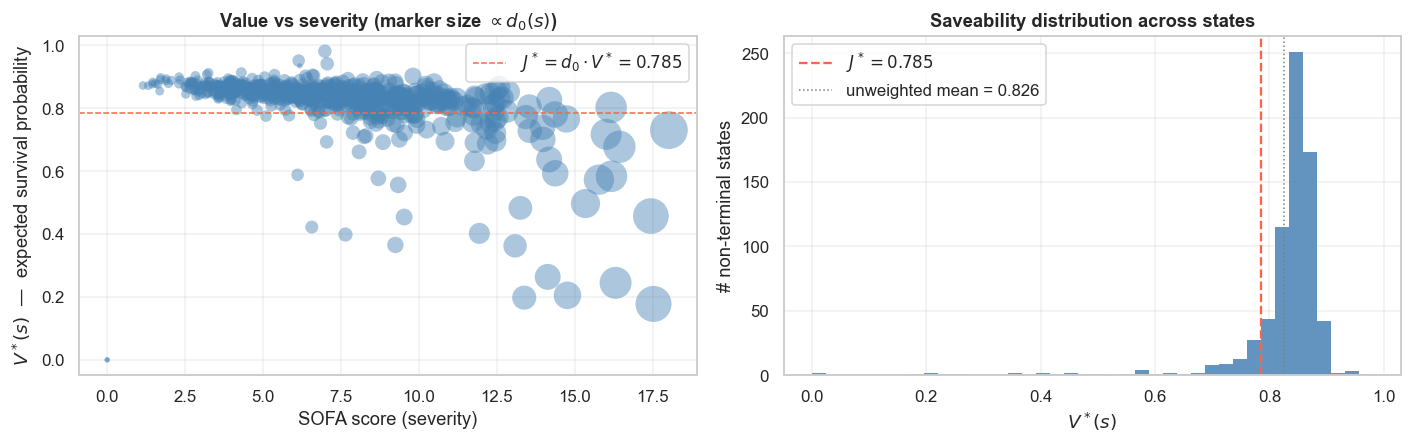

In [33]:
# Fig 6 — value landscape: V*(s) vs SOFA + V* distribution across states.
# V_VI_exact comes from the analytical linear solve and matches V_VI from
# Bellman iteration to numerical tolerance.

sofa_landscape_full = raw._sofa_scores
sofa_landscape_nt = sofa_landscape_full[NON_TERMINAL]
V_nt = V_VI_exact[NON_TERMINAL]
d0_nt = raw._d_0[NON_TERMINAL]

d0_max = d0_nt.max()
size_norm = d0_nt / d0_max
marker_sizes = 12 + 600 * size_norm

V_nt_unweighted_mean = float(V_nt.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

j_star_label = fr'$J^* = d_0 \cdot V^* = {J_VI_exact:.3f}$'
axes[0].scatter(sofa_landscape_nt, V_nt, s=marker_sizes, alpha=0.45,
                color='steelblue', edgecolor='none')
axes[0].axhline(J_VI_exact, color='tomato', linestyle='--', linewidth=1.0,
                label=j_star_label)
axes[0].set_xlabel('SOFA score (severity)')
axes[0].set_ylabel(r'$V^*(s)$  —  expected survival probability')
axes[0].set_title(r'Value vs severity (marker size $\propto d_0(s)$)',
                  fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

hist_j_label = fr'$J^* = {J_VI_exact:.3f}$'
hist_mean_label = f'unweighted mean = {V_nt_unweighted_mean:.3f}'
axes[1].hist(V_nt, bins=40, color='steelblue', alpha=0.85, edgecolor='none')
axes[1].axvline(J_VI_exact, color='tomato', linestyle='--', linewidth=1.5,
                label=hist_j_label)
axes[1].axvline(V_nt_unweighted_mean, color='gray', linestyle=':', linewidth=1.0,
                label=hist_mean_label)
axes[1].set_xlabel(r'$V^*(s)$')
axes[1].set_ylabel('# non-terminal states')
axes[1].set_title('Saveability distribution across states', fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_value_landscape.png', bbox_inches='tight')
plt.show()


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [34]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [35]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5703
Overall survival rate : 66.6%



In [36]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
